# Brain age prediction on MS data (m24 scans)

This notebook performs inference on month 24 MS scans.  
The trained unsmoothed brain age model is loaded and applied to month 24 unsmoothed asymmetry maps from MS patients.  
The resulting predictions are saved for later statistical analysis and plotting.

## Imports and paths

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import os
from pathlib import Path
import nibabel as nib
import matplotlib.pyplot as plt
import pyreadstat

# Import fastMONAI/fastai/MONAI tools used to recreate the same
# data pipeline and model architecture as during training.
# This is important because inference must use the same preprocessing
# and network structure as the trained model.
from fastMONAI.vision_all import *
from fastai.learner import Learner
from fastai.losses import L1LossFlat
from fastai.metrics import mae
from monai.networks.nets import Regressor

/opt/conda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define paths
ms_root = Path("/hus/home/aaasen/Master_thesis")


# Folder containing the month 24 MS asymmetry maps
image_dir = ms_root / "VBM_project_MS_m24" / "T1_scans"

# Metadata file containing participant information 
ms_participants_path = ms_root / "Metadata_OFAMS" / "follow_up_info.csv"

# Path to EDSS info
edss_path = Path("/hus/home/aaasen/Master_thesis/Metadata_OFAMS/edss.sav")

## Load MS metadata

In [3]:
df_part = pd.read_csv(ms_participants_path)
df_part.head()

,Unnamed: 0,Patnr,Sex_OFAMS10,Age_BL_OFAMS,Age_OFAMS10,EDSS_score_10
0,1,101,1.0,35.0,47.0,2
1,2,103,0.0,24.0,36.0,1
2,3,104,1.0,48.0,59.0,"1,5"
3,4,201,0.0,50.0,62.0,2
4,5,202,1.0,31.0,43.0,0


In [4]:
# Check data types for each column
df_part.dtypes

Unnamed: 0         int64
Patnr              int64
Sex_OFAMS10      float64
Age_BL_OFAMS     float64
Age_OFAMS10      float64
EDSS_score_10     object
dtype: object

In [5]:
# The metadata file contains baseline age.
# Since this notebook uses month 24 scans, approximately 2 years is added
# to the baseline age before it is used as the chronological age at inference.
df_part['Age_BL_OFAMS']= df_part['Age_BL_OFAMS'] + 2 # changes from the baseline age to the m24-age (2 years older)

# Rename selected columns
df_part = df_part.rename(columns={
    'Patnr': 'participant_id',
    'Sex_OFAMS10': 'sex',
    'Age_BL_OFAMS': 'age_m24'})

# Remove columns that are not needed for month 1 inference
df_part = df_part.drop(columns=["Unnamed: 0"])
df_part = df_part.drop(columns=["Age_OFAMS10"])
df_part = df_part.drop(columns=["EDSS_score_10"])

# Recode sex labels for easier interpretation
df_part["sex"] = df_part["sex"].map({0: "M", 1: "F"}) # 1=female, 0=male

In [6]:
df_part.head()

,participant_id,sex,age_m24
0,101,F,37.0
1,103,M,26.0
2,104,F,50.0
3,201,M,52.0
4,202,F,33.0


In [7]:
# Check data types again after cleaning
df_part.dtypes

participant_id      int64
sex                object
age_m24           float64
dtype: object

## Load EDSS data

In [8]:
edss_df, meta = pyreadstat.read_sav(edss_path)

edss_df.head()

,Patnr,BL_EDSSscore,M6_EDSSscore,M12_EDSSscore,M18_EDSSscore,M24_EDSSscore
0,101.0,1.5,2.0,2.0,2.0,2.0
1,103.0,2.5,1.0,1.0,1.0,0.0
2,104.0,1.5,1.5,2.0,1.5,1.5
3,201.0,1.5,2.5,2.5,2.5,2.5
4,202.0,1.0,1.0,1.0,0.0,0.0


In [9]:
edss_m24 = edss_df[["Patnr", "M24_EDSSscore"]].copy()

# Rename columns so that they match columns in df_part
edss_m24 = edss_m24.rename(columns={
    "Patnr": "participant_id",
    "M24_EDSSscore": "EDSS_m24"
})

edss_m24.head()

,participant_id,EDSS_m24
0,101.0,2.0
1,103.0,0.0
2,104.0,1.5
3,201.0,2.5
4,202.0,0.0


In [10]:
# Convert participant IDs to integers
edss_m24["participant_id"] = edss_m24["participant_id"].astype(int)

In [11]:
edss_m24.dtypes

participant_id      int64
EDSS_m24          float64
dtype: object

In [12]:
# Merge EDSS scores into the participant metadata
df_part = df_part.merge(
    edss_m24,
    on="participant_id",
    how="left"
)

# Count how many subjects have a EDSS score available
print("Number with m24-EDSS:", df_part["EDSS_m24"].notna().sum())
df_part.head()

Number with m24-EDSS: 86


,participant_id,sex,age_m24,EDSS_m24
0,101,F,37.0,2.0
1,103,M,26.0,0.0
2,104,F,50.0,1.5
3,201,M,52.0,2.5
4,202,F,33.0,0.0


## Remove subjects with missing age

In [13]:
# Remove subjects without month24-age
df_part = df_part.dropna(subset=["age_m24"])
df_part.head()

,participant_id,sex,age_m24,EDSS_m24
0,101,F,37.0,2.0
1,103,M,26.0,0.0
2,104,F,50.0,1.5
3,201,M,52.0,2.5
4,202,F,33.0,0.0


In [14]:
# Check the age range after removing missing values
min_age_new = df_part["age_m24"].min()
max_age_new = df_part["age_m24"].max()

print("Ages at month 24:")
print(f"Min age: {min_age_new}")
print(f"Max age: {max_age_new}")

Ages at month 24:
Min age: 21.0
Max age: 60.0


## Build dataframe linking images to subject metadata

In [15]:
# Create a list that will store one row per subject/image
rows = []

# Find all m24 asymmetry maps recursively
image_paths = sorted(image_dir.rglob("m24/mri/step4_warped/AI_mwrp1sub-*_ses-m24_ce-GADOLINIUM_*_affine.nii*"))

print("Found image files:", len(image_paths))
# Print one example path to verify that the correct files were found
if len(image_paths) > 0:
    print("Example:", image_paths[0])

# Loop through all image paths and extract metadata for each subject
for p in image_paths:
    fname = p.name

    # 1) Try to extract the participant ID from the file name
    # Example: "...sub-101..." gives participant_id = "101"
    participant_id = None
    if "sub-" in fname:
        try:
            participant_id = fname.split("sub-")[1].split("_")[0]
        except IndexError:
            participant_id = None

    # 2) Fallback option:
    # If the participant ID cannot be extracted from the file name,
    # try to extract it from the folder structure:
    # .../T1_scans/101/m24/...
    if participant_id is None:
        parts = p.parts
        if "T1_scans" in parts:
            i = parts.index("T1_scans")
            if i + 1 < len(parts):
                participant_id = parts[i + 1]

    # Skip the file if no participant ID can be found
    if participant_id is None:
        print("Could not parse subject ID from:", p)
        continue

    # Match the image file to the corresponding subject metadata
    match = df_part[df_part["participant_id"].astype(str) == str(participant_id)]

    # If exactly one matching metadata row is found, add the subject to the dataset
    if len(match) == 1:
        rows.append({
            "image_path": str(p),
            "participant_id": str(participant_id),
            "sex": match["sex"].values[0],
            "age_m24": match["age_m24"].values[0],
            "EDSS_m24": match["EDSS_m24"].values[0],
        })
    # If no metadata is found, report the missing match
    else:
        print("Metadata not found (or not unique) for subject:", participant_id, "matches:", len(match))

# Convert the collected rows into a DataFrame used for inference
df_ms = pd.DataFrame(rows)

print("Number of MS scans:", len(df_ms))
df_ms.head()

Found image files: 79
Example: /hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/101/m24/mri/step4_warped/AI_mwrp1sub-101_ses-m24_ce-GADOLINIUM_T1w_affine.nii
Number of MS scans: 79


,image_path,participant_id,sex,age_m24,EDSS_m24
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/101/m24/mri/step4_warped/AI_mwrp1sub-101_ses-m24_ce-GADOLINIUM_T1w_affine.nii,101,F,37.0,2.0
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1101/m24/mri/step4_warped/AI_mwrp1sub-1101_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1101,F,48.0,2.5
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1102/m24/mri/step4_warped/AI_mwrp1sub-1102_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1102,F,41.0,3.0
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1103/m24/mri/step4_warped/AI_mwrp1sub-1103_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1103,F,35.0,2.0
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1104/m24/mri/step4_warped/AI_mwrp1sub-1104_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1104,F,43.0,2.5


## Build DataBlock

In [16]:
import pickle

# Load the preprocessing parameters that were saved during model training.
# The same resampling and orientation settings must be used during inference
# to ensure that the MS images are processed in the same way as the training data.
preproc_path = Path("/hus/home/aaasen/Master_thesis/Brain_age_model/preproc_params.pkl")

with open(preproc_path, "rb") as f:
    preproc = pickle.load(f)

# Extract preprocessing settings
resample = preproc["resample"]
reorder  = preproc["reorder"]

print("Preprocessing parameters loaded successfully.")
print("Resample:", resample)
print("Reorder:", reorder)

Preprocessing parameters loaded successfully.
Resample: [1.5, 1.5, 1.5]
Reorder: False


In [17]:
# Define the input shape expected by the trained CNN
# This must match the input shape used during model training
in_shape = [1, 128, 160, 128]

# Define item-level transforms applied to each image before inference
# ZNormalization standardizes image intensities
# PadOrCrop ensures that all images have the same spatial dimensions
item_tfms = [ZNormalization(), PadOrCrop(in_shape[1:])]

In [18]:
# Create a MedDataBlock for inference
# The structure is the same as during training, but no train/validation
# split is needed because the full MS dataset is used for prediction.
dblock = MedDataBlock(
    blocks=(ImageBlock(cls=MedImage), RegressionBlock),
    splitter=None,  # no splitting for inference
    get_x=ColReader("image_path"),
    get_y=ColReader("age_m24"),  # chronological age, used as label for later comparison
    item_tfms=item_tfms,
    apply_reorder=reorder,
    target_spacing=resample
)
# Create dataloaders for the MS dataset
dls = dblock.dataloaders(df_ms, bs=4)

## Load model

In [19]:
# Recreate the CNN architecture used during training.
# The architecture must be identical to the saved model weights.
# Here, the model is a 3D regression network that outputs one value: predicted brain age.
model = Regressor(
    in_shape=in_shape,
    out_shape=1,
    channels=(64, 128, 256, 256, 256),
    strides=(2, 2, 2, 2),
    kernel_size=3,
    num_res_units=2
)

In [20]:
# Create a fastai Learner using the dataloaders and model architecture.
# L1LossFlat and MAE are included to match the training setup,
# although the main purpose here is inference rather than training.
learn = Learner(
    dls,
    model,
    loss_func=L1LossFlat(), 
    metrics=[mae],
)

# Set the path where the trained model weights are stored
learn.path = Path("/hus/home/aaasen/Master_thesis/Brain_age_model")
learn.model_dir = ""   # The model file is located directly in this folder, not inside a separate model_dir

# Load trained model weights
learn.load("baseline_best")

Saved file doesn't contain an optimizer state.


In [21]:
# Set the model to evaluation mode.
# This disables training-specific behavior and ensures stable inference.
learn.model.eval()

Regressor(
  (net): Sequential(
    (layer_0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 64, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (layer_1): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
         

## Brain age predictions and brain age gap

In [22]:
# Create a test dataloader from the full MS DataFrame.
# with_labels=True keeps the chronological ages available,
# so predictions can later be compared with true age.
test_dl = dls.test_dl(df_ms, with_labels=True)

In [23]:
# Generate brain age predictions for all MS m24-scans.
# Since splitter=None was used, this prediction step is performed
# on the full MS dataset.
preds, targs = learn.get_preds(dl=test_dl) # test = the whole dataset when splitter=None

# Convert predictions and true ages from tensors to NumPy arrays.
y_pred = preds.squeeze().cpu().numpy()
y_true = targs.squeeze().cpu().numpy()

# Store raw predicted brain age in the DataFrame.
df_ms["predicted_age"] = y_pred

# Calculate raw brain age gap (BAG)
# BAG = predicted brain age - chronological age
df_ms["brain_age_gap"] = y_pred - df_ms["age_m24"]

df_ms.head()

,image_path,participant_id,sex,age_m24,EDSS_m24,predicted_age,brain_age_gap
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/101/m24/mri/step4_warped/AI_mwrp1sub-101_ses-m24_ce-GADOLINIUM_T1w_affine.nii,101,F,37.0,2.0,41.782860,4.782860
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1101/m24/mri/step4_warped/AI_mwrp1sub-1101_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1101,F,48.0,2.5,45.975174,-2.024826
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1102/m24/mri/step4_warped/AI_mwrp1sub-1102_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1102,F,41.0,3.0,58.127739,17.127739
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1103/m24/mri/step4_warped/AI_mwrp1sub-1103_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1103,F,35.0,2.0,46.650864,11.650864
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1104/m24/mri/step4_warped/AI_mwrp1sub-1104_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1104,F,43.0,2.5,61.663292,18.663292


## Bias correction

In [24]:
# Load bias-correction parameters estimated from the training data
# These parameters correct for systematic age bias in the model predictions.
a, b = np.load("bias_correction_params.npy")

# Apply the bias-correction formula to the predictions
y_pred_bc = (y_pred - b) / a

# Store bias-corrected predicted age in the DataFrame
df_ms["predicted_age_bc"] = (df_ms["predicted_age"] - b) / a

# Calculate bias-corrected brain age gap
df_ms["brain_age_gap_bc"] = df_ms["predicted_age_bc"] - df_ms["age_m24"]

In [25]:
df_ms.head()

,image_path,participant_id,sex,age_m24,EDSS_m24,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
0,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/101/m24/mri/step4_warped/AI_mwrp1sub-101_ses-m24_ce-GADOLINIUM_T1w_affine.nii,101,F,37.0,2.0,41.782860,4.782860,42.112148,5.112148
1,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1101/m24/mri/step4_warped/AI_mwrp1sub-1101_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1101,F,48.0,2.5,45.975174,-2.024826,46.254944,-1.745056
2,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1102/m24/mri/step4_warped/AI_mwrp1sub-1102_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1102,F,41.0,3.0,58.127739,17.127739,58.263969,17.263969
3,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1103/m24/mri/step4_warped/AI_mwrp1sub-1103_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1103,F,35.0,2.0,46.650864,11.650864,46.922653,11.922653
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1104/m24/mri/step4_warped/AI_mwrp1sub-1104_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1104,F,43.0,2.5,61.663292,18.663292,61.757763,18.757763


## Prediction results

In [26]:
# Print a compact summary of the prediction results
print(df_ms[["participant_id", "sex", "age_m24", "predicted_age", "brain_age_gap", "predicted_age_bc", "brain_age_gap_bc", "EDSS_m24"]].head())
print("N =", len(df_ms))
print("Mean BAG:", df_ms["brain_age_gap"].mean())
print("Mean BAG (bias-corrected):", df_ms["brain_age_gap_bc"].mean())
print("Std BAG:", df_ms["brain_age_gap"].std())
print("Std BAG (bias-corrected):", df_ms["brain_age_gap_bc"].std())

  participant_id sex  age_m24  predicted_age  brain_age_gap  predicted_age_bc  \
0            101   F     37.0      41.782860       4.782860         42.112148   
1           1101   F     48.0      45.975174      -2.024826         46.254944   
2           1102   F     41.0      58.127739      17.127739         58.263969   
3           1103   F     35.0      46.650864      11.650864         46.922653   
4           1104   F     43.0      61.663292      18.663292         61.757763   

   brain_age_gap_bc  EDSS_m24  
0          5.112148       2.0  
1         -1.745056       2.5  
2         17.263969       3.0  
3         11.922653       2.0  
4         18.757763       2.5  
N = 79
Mean BAG: 7.239450527142875
Mean BAG (bias-corrected): 7.492925474915324
Std BAG: 7.7629586631316245
Std BAG (bias-corrected): 7.735684321529842


## Quality Control (QC)

### Extreme outliers

This step checks whether very large BAG values may be caused by preprocessing errors, empty images, incorrectly matched images, or other technical issues.  
The most extreme cases are inspected manually before the predictions are used in later analyses.

In [27]:
# Sort subjects by the absolute size of raw BAG
df_ms.sort_values("brain_age_gap", key=lambda x: abs(x), ascending=False).head(5)

,image_path,participant_id,sex,age_m24,EDSS_m24,predicted_age,brain_age_gap,predicted_age_bc,brain_age_gap_bc
19,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1414/m24/mri/step4_warped/AI_mwrp1sub-1414_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1414,F,29.0,2.5,58.766937,29.766937,58.895618,29.895618
58,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/705/m24/mri/step4_warped/AI_mwrp1sub-705_ses-m24_ce-GADOLINIUM_FLASH_affine.nii,705,F,21.0,1.0,44.774498,23.774498,45.068451,24.068451
43,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/303/m24/mri/step4_warped/AI_mwrp1sub-303_ses-m24_ce-GADOLINIUM_T1w_affine.nii,303,F,28.0,3.0,50.557701,22.557701,50.783344,22.783344
61,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/709/m24/mri/step4_warped/AI_mwrp1sub-709_ses-m24_ce-GADOLINIUM_T1w_affine.nii,709,F,36.0,1.5,55.631981,19.631981,55.797691,19.797691
4,/hus/home/aaasen/Master_thesis/VBM_project_MS_m24/T1_scans/1104/m24/mri/step4_warped/AI_mwrp1sub-1104_ses-m24_ce-GADOLINIUM_T1w_affine.nii,1104,F,43.0,2.5,61.663292,18.663292,61.757763,18.757763


Conclution: Nothing unusual with these asymmetry images.

In [28]:
# checking the input shape
xb, _ = dls.one_batch()
print(xb.shape)

torch.Size([4, 1, 128, 160, 128])


### Visualizing the 10 subjects with the largest and smallest BAG

The following cells visualize subjects with the smallest and largest BAG values.  
This is a quality-control step to check whether the asymmetry maps look plausible in subjects with extreme predictions.

In [29]:
# Select the 10 subjects with the smallest and largest raw BAG values.
# Here, low BAG values are referred to as best_cases and high BAG values
# as worst_cases for visual inspection.
best_cases = df_ms.sort_values("brain_age_gap").head(10)
worst_cases = df_ms.sort_values("brain_age_gap", ascending=False).head(10)

In [30]:
best_cases[
    ["participant_id", "sex", "age_m24", "predicted_age", "predicted_age_bc", "brain_age_gap", "brain_age_gap_bc", "EDSS_m24"]
    ]

,participant_id,sex,age_m24,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc,EDSS_m24
42,302,F,45.0,34.826488,35.237942,-10.173512,-9.762058,2.0
66,805,F,47.0,40.090809,40.440083,-6.909191,-6.559917,3.5
68,808,M,52.0,46.074844,46.353439,-5.925156,-5.646561,1.5
22,1503,M,47.0,41.779530,42.108856,-5.220470,-4.891144,2.5
74,815,M,47.0,43.110092,43.423706,-3.889908,-3.576294,1.0
56,703,M,50.0,46.897713,47.166588,-3.102287,-2.833412,2.5
62,801,F,43.0,40.561470,40.905186,-2.438530,-2.094814,2.5
1,1101,F,48.0,45.975174,46.254944,-2.024826,-1.745056,2.5
30,206,M,52.0,50.030998,50.262863,-1.969002,-1.737137,4.0
73,814,F,45.0,43.134087,43.447414,-1.865913,-1.552586,2.5


In [31]:
worst_cases[
    ["participant_id", "sex", "age_m24", "predicted_age", "predicted_age_bc", "brain_age_gap", "brain_age_gap_bc", "EDSS_m24"]
    ]

,participant_id,sex,age_m24,predicted_age,predicted_age_bc,brain_age_gap,brain_age_gap_bc,EDSS_m24
19,1414,F,29.0,58.766937,58.895618,29.766937,29.895618,2.5
58,705,F,21.0,44.774498,45.068451,23.774498,24.068451,1.0
43,303,F,28.0,50.557701,50.783344,22.557701,22.783344,3.0
61,709,F,36.0,55.631981,55.797691,19.631981,19.797691,1.5
4,1104,F,43.0,61.663292,61.757763,18.663292,18.757763,2.5
27,203,F,35.0,53.543835,53.734207,18.543835,18.734207,3.0
28,204,M,28.0,46.280407,46.556572,18.280407,18.556572,2.0
65,804,F,49.0,66.760490,66.794754,17.760490,17.794754,2.0
5,1105,F,33.0,50.135712,50.366341,17.135712,17.366341,3.0
2,1102,F,41.0,58.127739,58.263969,17.127739,17.263969,3.0


In [32]:
# Function for visualizing one axial slice from an asymmetry map.
# The default slice is the middle axial slice.
# The color scale is used to show positive and negative asymmetry values.
def show_asymmetry_image(image_path, title=None, slice_idx=None):
    img = nib.load(image_path).get_fdata()

    # Default: mid axial slice
    if slice_idx is None:
        slice_idx = img.shape[2] // 2

    plt.figure(figsize=(4, 4))
    plt.imshow(img[:, :, slice_idx].T, cmap="bwr", origin="lower")
    plt.colorbar(fraction=0.046)
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()

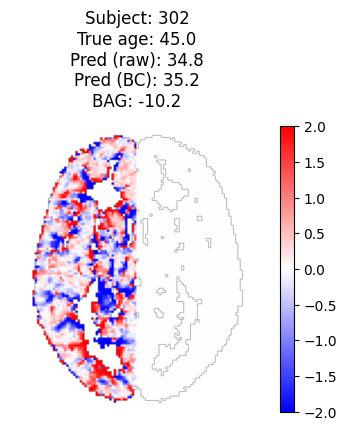

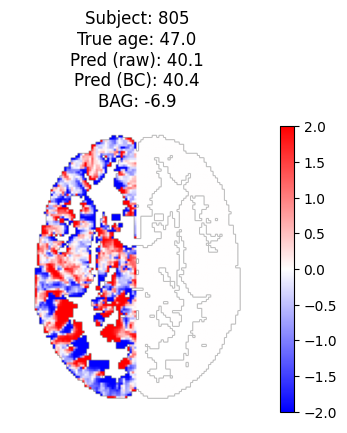

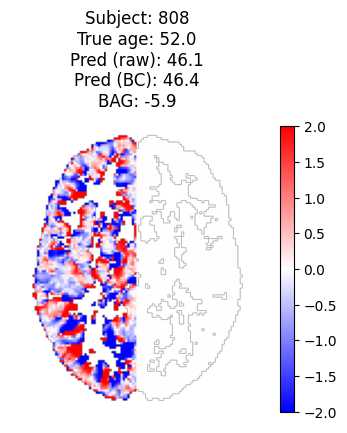

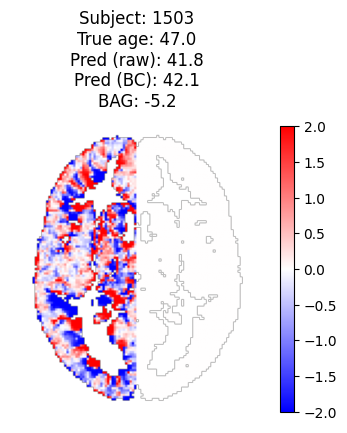

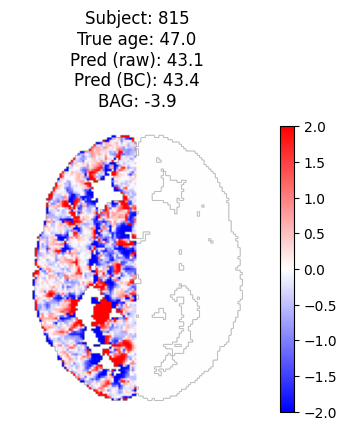

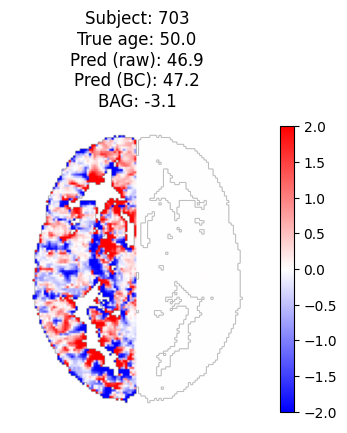

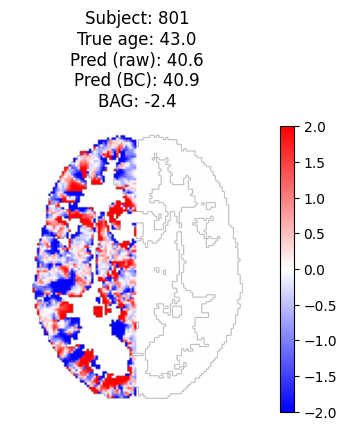

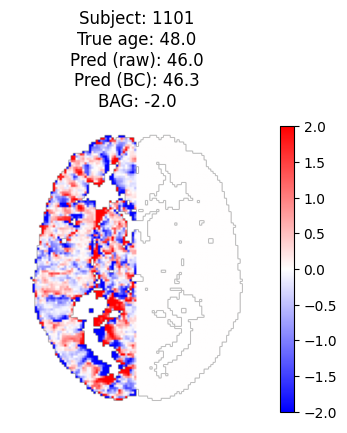

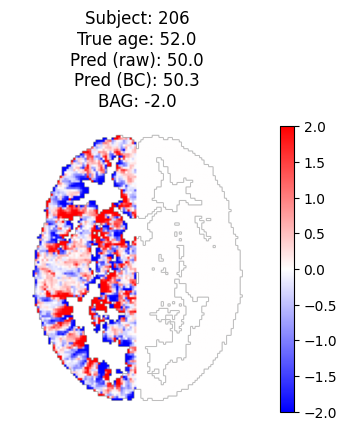

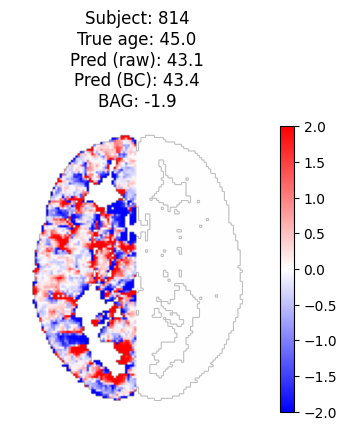

In [33]:
# Visualize subjects with the smallest BAG values / best cases
for _, row in best_cases.iterrows():
    title = (
    f"Subject: {row['participant_id']}\n"
    f"True age: {row['age_m24']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"BAG: {row['brain_age_gap']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

# In the colormap:
# red/positive values indicate rightward asymmetry,
# while blue/negative values indicate leftward asymmetry.

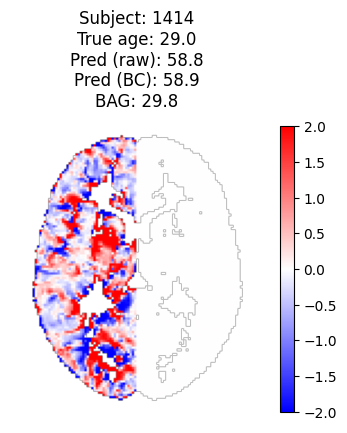

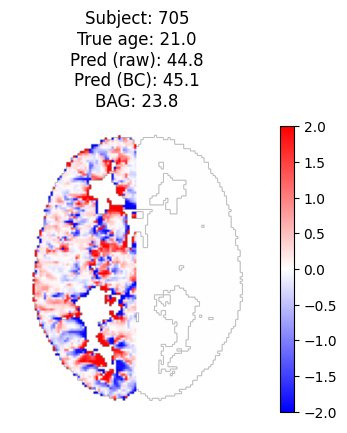

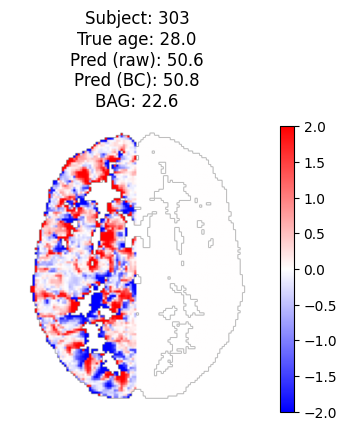

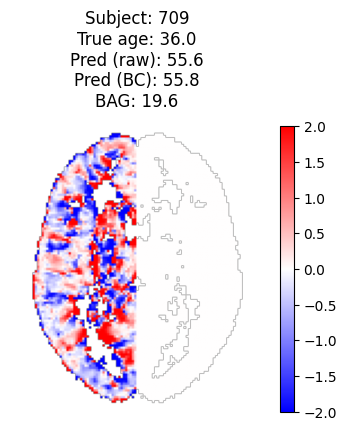

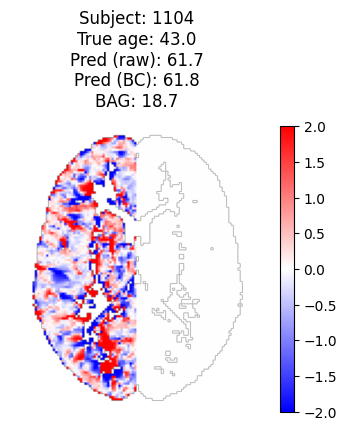

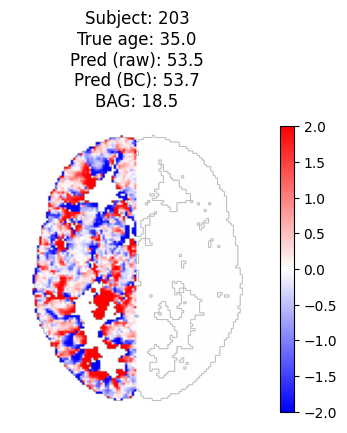

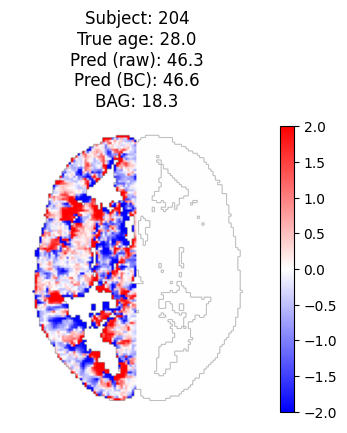

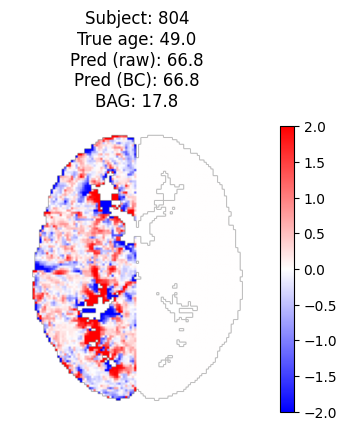

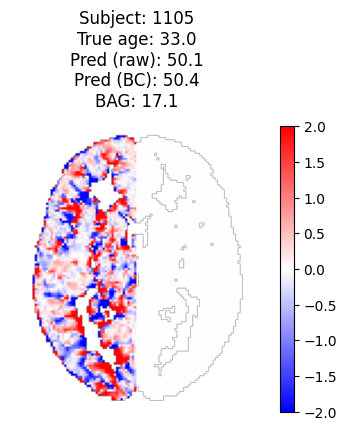

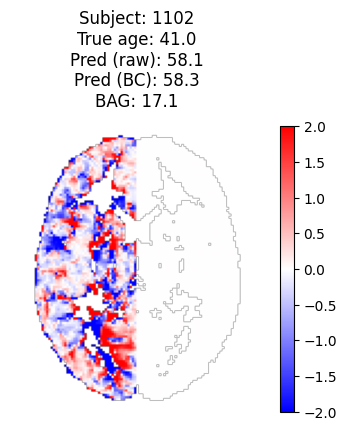

In [34]:
# Visualize subjects with the largest BAG values / worst cases
for _, row in worst_cases.iterrows():
    title = (
    f"Subject: {row['participant_id']}\n"
    f"True age: {row['age_m24']:.1f}\n"
    f"Pred (raw): {row['predicted_age']:.1f}\n"
    f"Pred (BC): {row['predicted_age_bc']:.1f}\n"
    f"BAG: {row['brain_age_gap']:.1f}")

    show_asymmetry_image(row["image_path"], title=title)

Conclusions: Nothing suspicious.

## Save results

In [64]:
#df_ms.to_csv("MS_brain_age_predictions_m24.csv", index=False)